In [1]:
from cil.io import ZEISSDataReader
import numpy as np
import os
os.chdir('/zhome/71/c/146676/main/')
import matplotlib.pyplot as plt
from cil.io import TIFFStackReader, TIFFWriter
import SimpleITK as sitk
import importlib
import plotly.io as pio
pio.renderers.default = "notebook"
from cil.framework import ImageData, ImageGeometry
import tifffile
from helpers import module_auxiliary as ma

In [2]:
path_NB = '/dtu-compute/msaca/sliceB_neutron_dtu/sliceB_neutron_registered_rotated/sliceB_neutron_registered_rotated_idx_####.tiff'
path_XB = '/dtu-compute/msaca/sliceB_xray_dtu/sliceB_xray_registered/rotated/sliceB_xray_rotated_idx_####.tiff'

A = np.arange(0,140)

paths_NB = ma.generate_paths(path_NB, A)
paths_XB = ma.generate_paths(path_XB, A)

recon_NB = []
recon_XB = []
for i in range(len(A)):
    recon_NB.append(tifffile.imread(paths_NB[i]).astype(np.float32))
    recon_XB.append(tifffile.imread(paths_XB[i]).astype(np.float32))

recon_NB = np.stack(recon_NB)
recon_XB = np.stack(recon_XB)


In [3]:
def segment_rock(input_image, threshold = 0.01):
    # Downsample by factor of 3
    # Compute new size and spacing
    factor = 3
    new_size = [int(s / factor) for s in input_image.GetSize()]
    new_spacing = [s * factor for s in input_image.GetSpacing()]

    # Resample the image (downsampling)
    resample = sitk.ResampleImageFilter()
    resample.SetSize(new_size)
    resample.SetOutputSpacing(new_spacing)
    resample.SetInterpolator(sitk.sitkLinear)
    resample.SetOutputOrigin(input_image.GetOrigin())  # Copy origin
    resample.SetOutputDirection(input_image.GetDirection())  # Copy direction
    downsampled_image = resample.Execute(input_image)


    # Apply Gaussian smoothing
    smoothed_image = sitk.SmoothingRecursiveGaussian(downsampled_image, sigma=0.01)

    # Threshold-based segmentation (choose a threshold manually)
    lower_threshold = threshold  # Change this value based on your data
    upper_threshold = 255
    binary_image = sitk.BinaryThreshold(smoothed_image, lowerThreshold=lower_threshold, upperThreshold=upper_threshold, insideValue=1, outsideValue=0)

    # **Keep only the largest connected component of class 1 (object)**
    cc_object = sitk.ConnectedComponent(binary_image)  # Label connected regions
    object_sizes = sitk.LabelShapeStatisticsImageFilter()
    object_sizes.Execute(cc_object)
    largest_label = max(object_sizes.GetLabels(), key=lambda l: object_sizes.GetPhysicalSize(l))
    largest_object = sitk.BinaryThreshold(cc_object, lowerThreshold=largest_label, upperThreshold=largest_label, insideValue=1, outsideValue=0)

    # **Keep only the largest connected component of class 0 (background)**
    inverted_binary = sitk.BinaryNot(largest_object)  # Invert image
    cc_background = sitk.ConnectedComponent(inverted_binary)
    background_sizes = sitk.LabelShapeStatisticsImageFilter()
    background_sizes.Execute(cc_background)
    largest_label_bg = max(background_sizes.GetLabels(), key=lambda l: background_sizes.GetPhysicalSize(l))
    largest_background = sitk.BinaryThreshold(cc_background, lowerThreshold=largest_label_bg, upperThreshold=largest_label_bg, insideValue=1, outsideValue=0)

    # Invert background back to 0
    final_segmented = sitk.BinaryNot(largest_background)

    # Resample back to original resolution (upsampling)
    resample.SetSize(input_image.GetSize())
    resample.SetOutputSpacing(input_image.GetSpacing())
    resample.SetInterpolator(sitk.sitkNearestNeighbor)  
    resample.SetOutputOrigin(input_image.GetOrigin())  
    resample.SetOutputDirection(input_image.GetDirection())  
    final_segmented = resample.Execute(final_segmented)
    return final_segmented

In [6]:
NB_e = sitk.GetArrayFromImage(segment_rock(sitk.GetImageFromArray(recon_NB), threshold = 0.47)).astype(bool).astype(np.int8)
XB_e = sitk.GetArrayFromImage(segment_rock(sitk.GetImageFromArray(recon_XB), threshold = 0.17)).astype(bool).astype(np.int8)

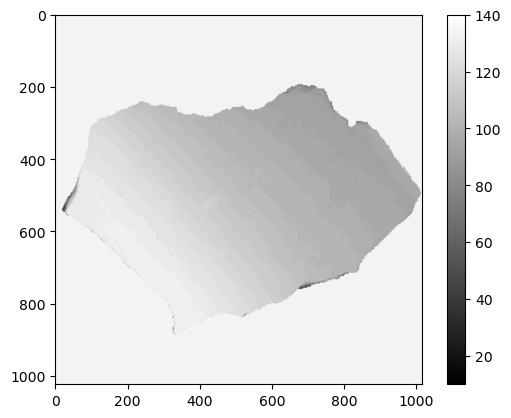

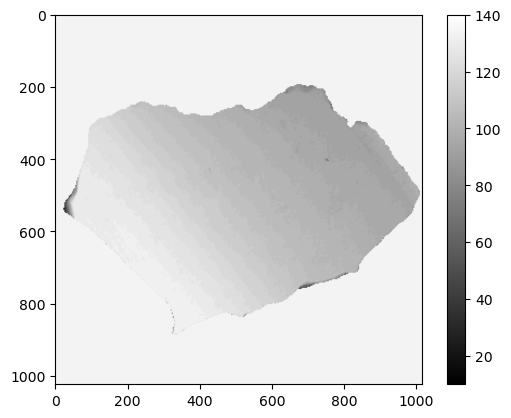

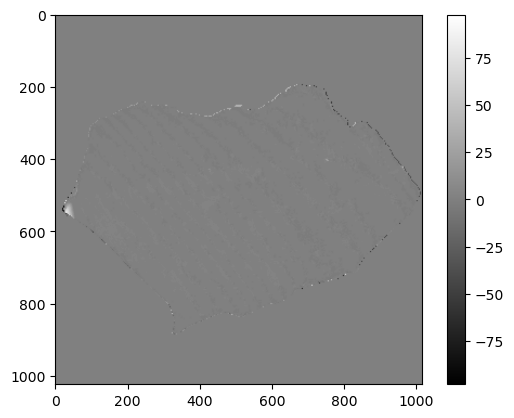

In [7]:
XB_d = np.diff(XB_e,axis=0)
rev_first_true_idx = np.argmax(XB_e[-5:5:-1], axis=0)+5
edge_index_XBB_upper= XB_e.shape[0] - 1 - rev_first_true_idx
temp = edge_index_XBB_upper
plt.imshow(edge_index_XBB_upper)
plt.clim([10,140])
plt.colorbar()
plt.show()

NB_d = np.diff(NB_e,axis=0)
rev_first_true_idx = np.argmax(NB_e[-5:5:-1], axis=0)+5
edge_index_XBB_upper= NB_e.shape[0] - 1 - rev_first_true_idx
plt.imshow(edge_index_XBB_upper)
plt.clim([10,140])
plt.colorbar()
plt.show()

plt.imshow(temp - edge_index_XBB_upper)
#plt.clim([0,50])
plt.colorbar()
plt.show()

In [8]:
NB_d = np.diff(NB_e,axis=0)
edge_index_NB_lower = np.argmax(NB_d[15:-15], axis=0)+15
edge_index_NB_lower[np.all(NB_d == False, axis=0)] = -1
edge_index_NB_lower = np.clip(edge_index_NB_lower*NB_e[90],a_min=10,a_max=135)

NB_d = np.diff(NB_e,axis=1)
rev_first_true_idx = np.argmax(NB_e[-5:5:-1], axis=0)+5
edge_index_NB_upper= NB_e.shape[0] - 1 - rev_first_true_idx
edge_index_NB_upper[np.all(NB_e == False, axis=0)] = -1
edge_index_NB_upper = np.clip(edge_index_NB_upper,a_min=10,a_max=135)

XB_d = np.diff(XB_e,axis=0)
edge_index_XB_lower = np.argmax(XB_d[15:-15], axis=0)+15
edge_index_XB_lower[np.all(XB_d == False, axis=0)] = -1
edge_index_XB_lower = np.clip(edge_index_XB_lower*XB_e[90],a_min=10,a_max=135)

XB_d = np.diff(XB_e,axis=0)
rev_first_true_idx = np.argmax(XB_e[-5:5:-1, :], axis=0)+5
edge_index_XB_upper= XB_e.shape[0] - 1 - rev_first_true_idx
edge_index_XB_upper[np.all(XB_e == False, axis=0)] = -1
edge_index_XB_upper = np.clip(edge_index_XB_upper,a_min=10,a_max=135)

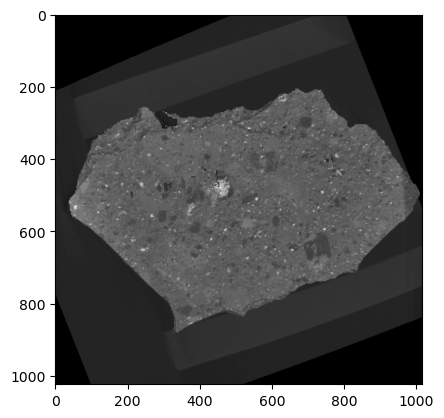

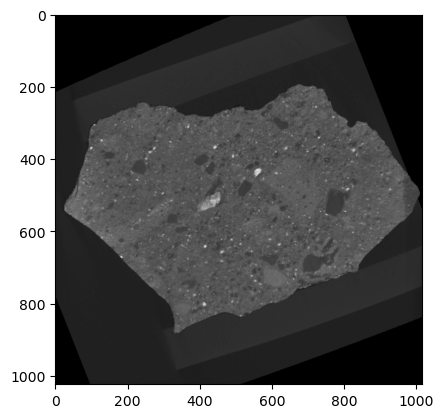

In [9]:
nz, ny, nx = np.shape(recon_NB)
edge_layer_NB_l = []
edge_layer_XB_l = []
for i in range(-10,10):
    edge_layer_NB_l.append(recon_NB[edge_index_NB_lower+i, np.arange(ny)[:,None], np.arange(nx)])
    edge_layer_XB_l.append(recon_XB[edge_index_NB_lower+i, np.arange(ny)[:,None], np.arange(nx)])


edge_layer_NB_u = []
edge_layer_XB_u = []
for i in range(-10,5):
    edge_layer_NB_u.append(recon_NB[edge_index_NB_upper+i, np.arange(ny)[:,None], np.arange(nx)])
    edge_layer_XB_u.append(recon_XB[edge_index_NB_upper+i, np.arange(ny)[:,None], np.arange(nx)])



plt.imshow(edge_layer_XB_l[15])
plt.show()
plt.imshow(edge_layer_XB_u[5])
plt.show()
# edge_layer_l corresponds to surface slice

In [10]:
path_eds = '/dtu-compute/msaca/sliceB_eds/Slice B1 (PSI CT, X-ray CT)/Raw data/BB_slice_B_EDS_map/BB_sliceB_map2_O_smooth.tif'
EDS = (tifffile.imread(path_eds)).astype(np.float32)[:,:,2]
plt.imshow((EDS>100)*1.0)
plt.savefig('/dtu-compute/msaca/cache/plot1.png')
plt.close('all')

In [16]:
def registrator(fixed, moving, thresholds = [0.025, 30], sampling_percentage = 0.1, max_iter = 1000, learning_rate = 1,mask=None):

    fixed_d = sitk.BinaryThreshold(fixed, lowerThreshold=thresholds[0], upperThreshold=float("inf"), insideValue=1, outsideValue=0)
    moving_d = sitk.BinaryThreshold(moving, lowerThreshold=thresholds[1], upperThreshold=float("inf"), insideValue=1, outsideValue=0)
    fixed_d =sitk.Cast(fixed_d, sitk.sitkFloat32)
    moving_d =sitk.Cast(moving_d, sitk.sitkFloat32)

    initial_transform = sitk.Similarity2DTransform()
    initial_transform.SetMatrix([1.0, 0.0,
                                0.0, 1.0])

    # Set the translation to zero
    initial_transform.SetTranslation([0.0, 0.0])
    initial_transform.SetScale(1.0)

    registration = sitk.ImageRegistrationMethod()
    registration.SetInitialTransform(initial_transform)
    registration.SetMetricAsMeanSquares()
    if mask is not None:
        mask = sitk.GetImageFromArray(mask)
        mask.CopyInformation(fixed_d) 
        registration.SetMetricFixedMask(mask)  # Apply mask to the fixed image

    registration.SetMetricSamplingStrategy(registration.RANDOM)
    registration.SetMetricSamplingPercentage(sampling_percentage)

    registration.SetOptimizerAsGradientDescent(
        learningRate=learning_rate,
        numberOfIterations=max_iter,
        convergenceMinimumValue=-1e-16,
        convergenceWindowSize=1000
        )

    registration.SetInterpolator(sitk.sitkLinear)
    registration.Execute(fixed_d, moving_d)
    transform = registration.GetInitialTransform()
    return transform

def resampler(fixed, moving, transform):
    resampler = sitk.ResampleImageFilter()
    resampler.SetReferenceImage(fixed)  # Reference image (fixed)
    resampler.SetInterpolator(sitk.sitkLinear)   # Interpolation method
    resampler.SetTransform(transform)    # Apply the initial transform (aligned centroids)
    resampler.SetOutputPixelType(fixed.GetPixelID())
    resampler.SetOutputSpacing(fixed.GetSpacing())  # Ensure the spacing is preserved
    resampler.SetOutputOrigin(fixed.GetOrigin())  # Preserve origin
    resampler.SetOutputDirection(fixed.GetDirection())
    moving = resampler.Execute(moving)
    return moving

In [ ]:
transforms = []

EDS_ = sitk.GetImageFromArray(EDS)
upsampled = np.flipud(np.kron(edge_layer_XB_l[15], np.ones((7, 7))).astype(np.float32))
recon_XB_ = sitk.GetImageFromArray(upsampled)


transforms.append(registrator(EDS_, recon_XB_, thresholds = [100.0, 0.17], sampling_percentage = 0.3, max_iter = 400, learning_rate = 0.3))
moving_temp_X = resampler(EDS_, recon_XB_, transforms[0])



#transforms.append(registrator(EDS_, moving_temp, thresholds = [100.0, 0.17], sampling_percentage = 0.4, max_iter = 20, learning_rate = 0.1))
#moving_temp = resampler(EDS_, moving_temp, transforms[1])


In [72]:
upsampled = np.flipud(np.kron(edge_layer_NB_l[15], np.ones((7, 7))).astype(np.float32))
recon_NB_ = sitk.GetImageFromArray(upsampled)
moving_temp_N = resampler(EDS_, recon_NB_, transforms[0])

In [22]:
box1 = [000,4000,100,4000]
box2 = [000,4000,100,4000]
box1 = [00,500,3100,3800]
box2 = [00,500,3100,3800]

path_eds = '/dtu-compute/msaca/sliceB_eds/Slice B1 (PSI CT, X-ray CT)/Raw data/BB_slice_B_EDS_map/BB_sliceB_map2_O_smooth.tif'
plt.imshow((sitk.GetArrayFromImage(EDS_))[box1[0]:box1[1],box1[2]:box1[3]]*1.0)
plt.savefig('/dtu-compute/msaca/cache/plot1.png')
plt.close('all')



path_eds = '/dtu-compute/msaca/sliceB_eds/Slice B1 (PSI CT, X-ray CT)/Raw data/BB_slice_B_EDS_map/BB_sliceB_map2_O_smooth.tif'
plt.imshow((sitk.GetArrayFromImage(moving_temp))[box2[0]:box2[1],box2[2]:box2[3]]*1.0)
plt.savefig('/dtu-compute/msaca/cache/plot2.png')
plt.close('all')

In [76]:
fixed_points = np.array([
    [300, 720],  # (row, column) format
    [2500, 2650],
    [30, 3340]
], dtype=np.float64)

moving_points = np.array([
    [175, 1440],  # Matching indices in moving image
    [2250, 2750],
    [250, 3630]
], dtype=np.float64)


# Convert index coordinates to physical space (important for SimpleITK)
def indices_to_physical(image, points):
    return [coord for p in points for coord in image.TransformIndexToPhysicalPoint([int(p[1]), int(p[0])])]


fixed_landmarks = indices_to_physical(EDS_, fixed_points)
moving_landmarks = indices_to_physical(moving_temp, moving_points)

# Initialize a transformation using the landmark points
transform = sitk.AffineTransform(2)  # You can also use AffineTransform(2)
transform = sitk.LandmarkBasedTransformInitializer(transform, fixed_landmarks, moving_landmarks)
transforms.append(transform)
moving_out = resampler(EDS_, moving_temp, transform)
moving_out_N = resampler(EDS_, moving_temp_N, transform)



In [69]:
print(np.max(m3))

0.7799849


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.274999976158142].


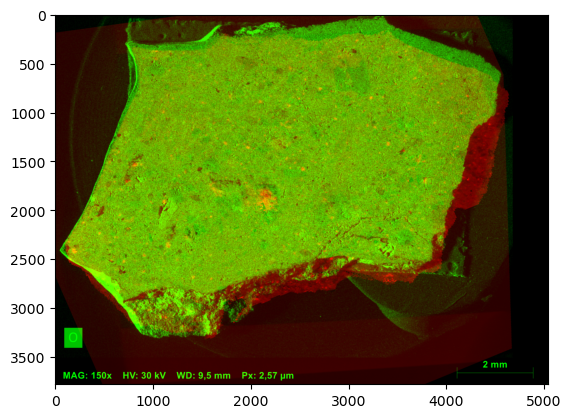

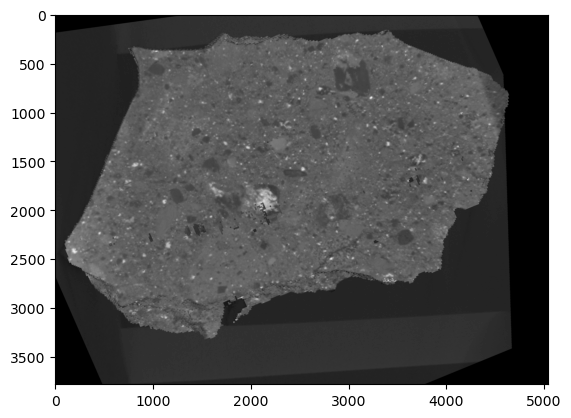

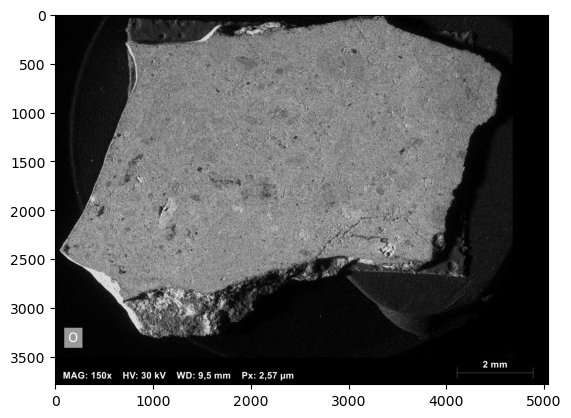

In [ ]:


m2 = sitk.GetArrayFromImage(EDS_)
plt.figure()
nx,ny = np.shape(m1)
c = np.zeros((nx,ny, 3))
for i in range(5,6):
    c[:,:,0] = m1*3*i/10
    c[:,:,1] = m2/200
    plt.imshow(c)
    plt.clim([0,200])
    plt.savefig('/dtu-compute/msaca/cache/plots3/output'+str(i)+'.png', dpi=200)
plt.figure()
plt.imshow(m1*1)
plt.savefig('/dtu-compute/msaca/cache/plots3/output0.png', dpi=200)
plt.figure()
plt.imshow(m2*1)
plt.savefig('/dtu-compute/msaca/cache/plots3/output00.png', dpi=200)

In [77]:
fixed_points = np.array([
    [300, 720],  # (row, column) format
    [2500, 2650],
    [30, 3340],
    [2000,4000]
], dtype=np.float64)

moving_points = np.array([
    [330, 720],  # Matching indices in moving image
    [2650, 2650],
    [170, 3360],
    [2170,4050]
], dtype=np.float64)


# Convert index coordinates to physical space (important for SimpleITK)
def indices_to_physical(image, points):
    return [coord for p in points for coord in image.TransformIndexToPhysicalPoint([int(p[1]), int(p[0])])]


fixed_landmarks = indices_to_physical(EDS_, fixed_points)
moving_landmarks = indices_to_physical(moving_temp, moving_points)

# Initialize a transformation using the landmark points
transform = sitk.AffineTransform(2)  # You can also use AffineTransform(2)
transform = sitk.LandmarkBasedTransformInitializer(transform, fixed_landmarks, moving_landmarks)
transforms.append(transform)
moving_out = resampler(EDS_, moving_out, transform)
moving_out_N = resampler(EDS_, moving_out_N, transform)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.274999976158142].


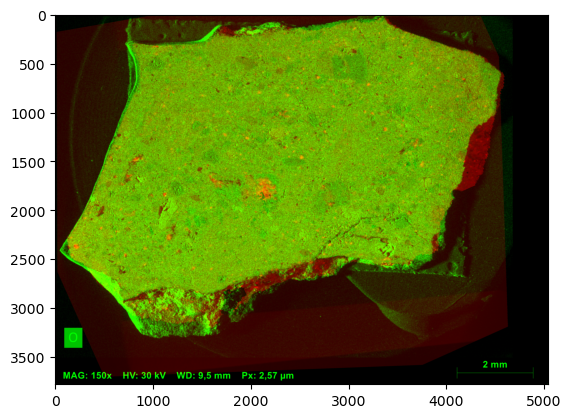

In [78]:
m1 = sitk.GetArrayFromImage(moving_out)
m2 = sitk.GetArrayFromImage(EDS_)
m1 = sitk.GetArrayFromImage(moving_out)
m3 = sitk.GetArrayFromImage(moving_out_N)
np.save('/dtu-compute/msaca/cache/sliceB_neutron_EDS_surface.npy', m3)
np.save('/dtu-compute/msaca/cache/sliceB_xray_EDS_surface.npy', m1)
tifffile.imwrite('/dtu-compute/msaca/cache/sliceB_neutron_EDS_surface.tif', (m3*255).astype(np.uint8))
tifffile.imwrite('/dtu-compute/msaca/cache/sliceB_xray_EDS_surface.tif', (m1*255).astype(np.uint8))
plt.figure()
nx,ny = np.shape(m1)
c = np.zeros((nx,ny, 3))
for i in range(5,6):
    c[:,:,0] = m1*3*i/10
    c[:,:,1] = m2/200
    plt.imshow(c)
    plt.clim([0,200])
    plt.savefig('/dtu-compute/msaca/cache/plots3/output'+str(i)+'.png', dpi=200)